# Histogram eigenvalues của H, heatmap của H (n ≤ 20).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hat_matrix(H: list[list[float]], eigenvalues: list[float], save_path: str = None):
    """
    Vẽ 2 biểu đồ bắt buộc cho F2:
      1. Heatmap của H (chỉ khi n <= 20)
      2. Histogram của eigenvalues (chứng minh chỉ có giá trị 0 hoặc 1)

    Tham số
    -------
    H            : Hat matrix.
    eigenvalues  : Danh sách eigenvalues của H.
    save_path    : Nếu không None, lưu figure vào đường dẫn này.
    """


    n = len(H)
    n_plots = 2 if n <= 20 else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    # Subplot 1 — Histogram eigenvalues
    ax = axes[0]
    ax.hist(eigenvalues, bins=20, edgecolor="black")
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="0")
    ax.axvline(x=1, color="red", linestyle="--", linewidth=1.5, label="1")
    ax.set_title("Eigenvalues of Hat Matrix H")
    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Count")
    ax.legend()

    # Subplot 2 — Heatmap H (chỉ khi n <= 20)
    if n <= 20:
        ax2 = axes[1]
        import numpy as np
        sns.heatmap(
            np.array(H),
            annot=(n <= 10),
            fmt=".2f",
            cmap="coolwarm",
            ax=ax2,
        )
        ax2.set_title("Hat Matrix H")
        ax2.set_xlabel("Observation index")
        ax2.set_ylabel("Observation index")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()



In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))  # project root
sys.path.insert(0, os.getcwd())                       # part1/

from ols_implementation import hat_matrix
from utils import make_multifeature_data
from config import RANDOM_STATE

In [3]:
# Tạo X với n=10 quan sát, p=3 features → H có kích thước 10x10
X, *_ = make_multifeature_data(n=10, p=3, sigma=1.0, seed=RANDOM_STATE)

result = hat_matrix(X)
H           = result['H']
eigenvalues = result['eigenvalues']

print(f"Shape của H: {len(H)} x {len(H[0])}")
print(f"rank(H)      = {result['rank']}  (= p+1 = 4)")
print(f"Idempotent   : {result['is_idempotent']}")
print(f"Symmetric    : {result['is_symmetric']}")

Shape của H: 10 x 10
rank(H)      = 4  (= p+1 = 4)
Idempotent   : True
Symmetric    : True


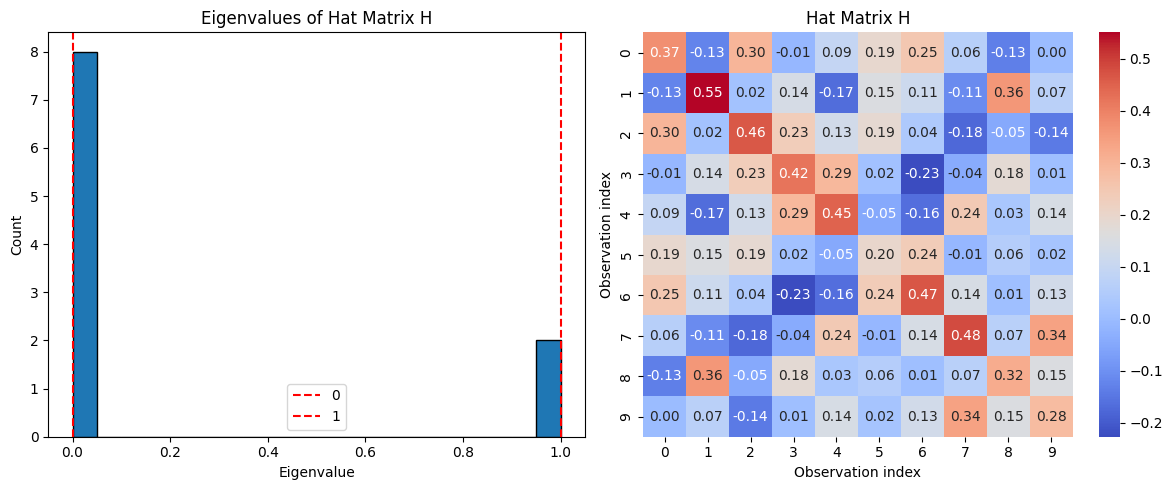

In [4]:
plot_hat_matrix(H, eigenvalues)